### Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

### Dangerous Points

In [2]:
base_dir = Path("..")

#Load data
forecast = pd.read_csv(base_dir / "transformed_data" / "combined_station_groups_1km" / "app_assets" / "forecast_ranking.csv")
historical = pd.read_csv(base_dir / "transformed_data" / "combined_station_groups_1km" / "app_assets" / "historical_ranking.csv")
dangerous_points = pd.read_excel(base_dir / "data" / "Dynamische lijst 2025.xlsx")
with open(base_dir / "transformed_data" / "combined_station_groups_1km" / "models" / "next_month_catboost_grouped_bike_1km_metadata.json") as f:
    metadata = json.load(f)

print(f"Forecast groups: {len(forecast)}")
print(f"Historical groups: {len(historical)}")
print(f"Official dangerous points: {len(dangerous_points)}")
print(f"\nForecast columns: {forecast.columns.tolist()}")
print(f"\nDangerous points columns: {dangerous_points.columns.tolist()}")

Forecast groups: 86
Historical groups: 86
Official dangerous points: 286

Forecast columns: ['group_id', 'group_name', 'gemeente', 'lat', 'long', 'member_site_count', 'member_site_ids', 'year', 'month', 'predicted_probability', 'predicted_label', 'forecast_risk_rank', 'risk_label', 'hidden_risk_spot']

Dangerous points columns: ['ObjectID', 'Provincie', 'Gemeente', 'Omschrijving']


In [4]:
#High risk groups
high_risk = forecast[forecast["predicted_label"] == 1].sort_values(
    "predicted_probability", ascending=False
)

print(f"Groups predicted as high risk: {len(high_risk)} of {len(forecast)}")
print(f"\nTop 10 highest risk groups:")
print(high_risk[["group_name", "gemeente", "predicted_probability", "forecast_risk_rank"]].head(10).to_string(index=False))

#Hidden risk sposts
official_municipalities = set(dangerous_points["Gemeente"].str.strip().str.lower())
forecast["gemeente_lower"] = forecast["gemeente"].str.strip().str.lower()

hidden_risk = forecast[
    (forecast["predicted_label"] == 1) &
    (~forecast["gemeente_lower"].isin(official_municipalities))
].sort_values("predicted_probability", ascending=False)

print(f"\nHidden risk spots (high risk but NOT in official list): {len(hidden_risk)}")
print(hidden_risk[["group_name", "gemeente", "predicted_probability"]].to_string(index=False))

Groups predicted as high risk: 24 of 86

Top 10 highest risk groups:
                    group_name    gemeente  predicted_probability  forecast_risk_rank
Eco Display Classic Budastraat    Kortrijk               0.992455                   1
                  leuven totem      Leuven               0.985848                   2
               Leuven teller 1      Leuven               0.981742                   3
                    Kortrijk 1    Kortrijk               0.962539                   4
             Dendermonde totem Dendermonde               0.947437                   5
                    Oostende 2    Oostende               0.941856                   6
              Nieuwpoort totem  Nieuwpoort               0.861920                   7
           Nieuwpoort teller 1  Nieuwpoort               0.858668                   8
                      Tienen 2      Tienen               0.846395                   9
                 Gent teller 1        Gent               0.808418      

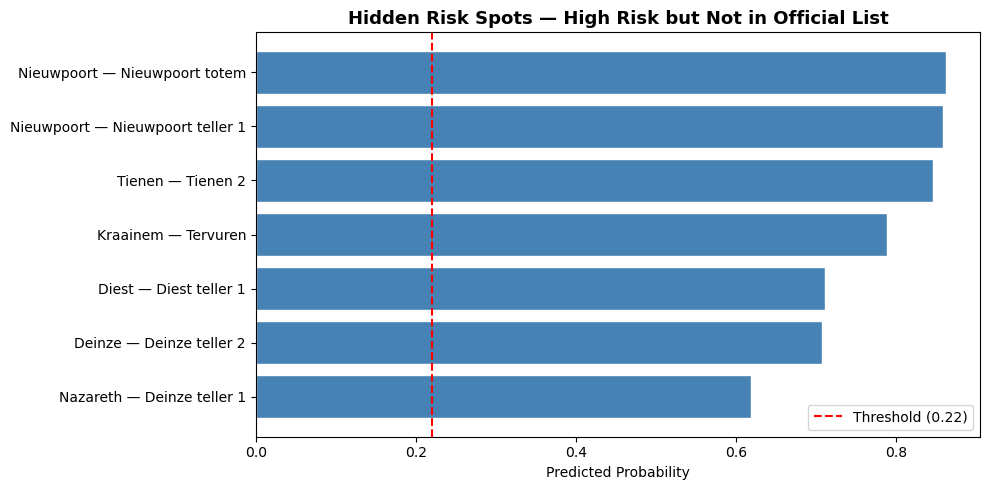

In [5]:
#Hidden risk spots plot
plt.figure(figsize=(10, 5))
plt.barh(
    hidden_risk["gemeente"] + " — " + hidden_risk["group_name"],
    hidden_risk["predicted_probability"],
    color="steelblue", edgecolor="white"
)
plt.axvline(x=metadata["threshold"], color="red", linestyle="--", label=f"Threshold ({metadata['threshold']})")
plt.title("Hidden Risk Spots — High Risk but Not in Official List", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Probability")
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()